# Task 2 – Technical Indicator Analysis

This notebook:
1. Loads historical price data for AAPL, AMZN, GOOG, META, MSFT, and NVDA from `data/`.
2. Applies TA‑Lib indicators (SMA‑20, RSI‑14, MACD) via `src.financial_analysis.apply_technical_indicators`.
3. Computes volatility, cumulative return, and maximum drawdown per ticker via `src.financial_analysis.calculate_financial_metrics`.
4. Visualises price vs SMA, RSI bands, and MACD to illustrate different market regimes.

In [3]:
# Install requirements if not already installed
%pip install yfinance TA-Lib pynance seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.stock_data import load_stock_csv
from src.financial_analysis import apply_technical_indicators, calculate_financial_metrics

%matplotlib inline
sns.set_style('whitegrid')

/Users/sintayehuabaynhe/Public/panic/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load Data
We will load data for a sample ticker (e.g., AAPL) from the local CSV files.

In [5]:
# Load data for all available stocks
import glob
import os

data_dir = '../data'
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
# Filter out the raw_analyst_ratings.csv if present, or just look for the tickers we know
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA']
stock_data = {}

for ticker in tickers:
    file_path = os.path.join(data_dir, f'{ticker}.csv')
    if os.path.exists(file_path):
        df = load_stock_csv(file_path)
        if not df.empty:
            stock_data[ticker] = df
            print(f"Loaded {ticker} with {len(df)} rows")

# Select one for detailed visualization
ticker = 'AAPL'
df = stock_data.get(ticker)
if df is not None:
    df.head()
else:
    print(f"Data for {ticker} not found.")

Loading data from ../data/AAPL.csv...
Loaded AAPL with 3774 rows
Loading data from ../data/AMZN.csv...
Loaded AMZN with 3774 rows
Loading data from ../data/GOOG.csv...
Loaded GOOG with 3774 rows
Loading data from ../data/META.csv...
Loaded META with 2923 rows
Loading data from ../data/MSFT.csv...
Loaded MSFT with 3774 rows
Loading data from ../data/NVDA.csv...
Loaded NVDA with 3774 rows


## 2. Apply Technical Indicators (TA-Lib)

In [6]:
df_ta = apply_technical_indicators(df)
df_ta[['Close', 'SMA_20', 'RSI_14', 'MACD']].tail()

,Close,SMA_20,RSI_14,MACD
Date,,,,
2023-12-22,191.788757,191.856618,54.672784,2.633141
2023-12-26,191.243912,192.018094,53.090049,2.304751
2023-12-27,191.342972,192.154308,53.354446,2.029104
2023-12-28,191.768951,192.362839,54.540999,1.823998
2023-12-29,190.728775,192.490633,51.121347,1.559539


## 3. Visualization

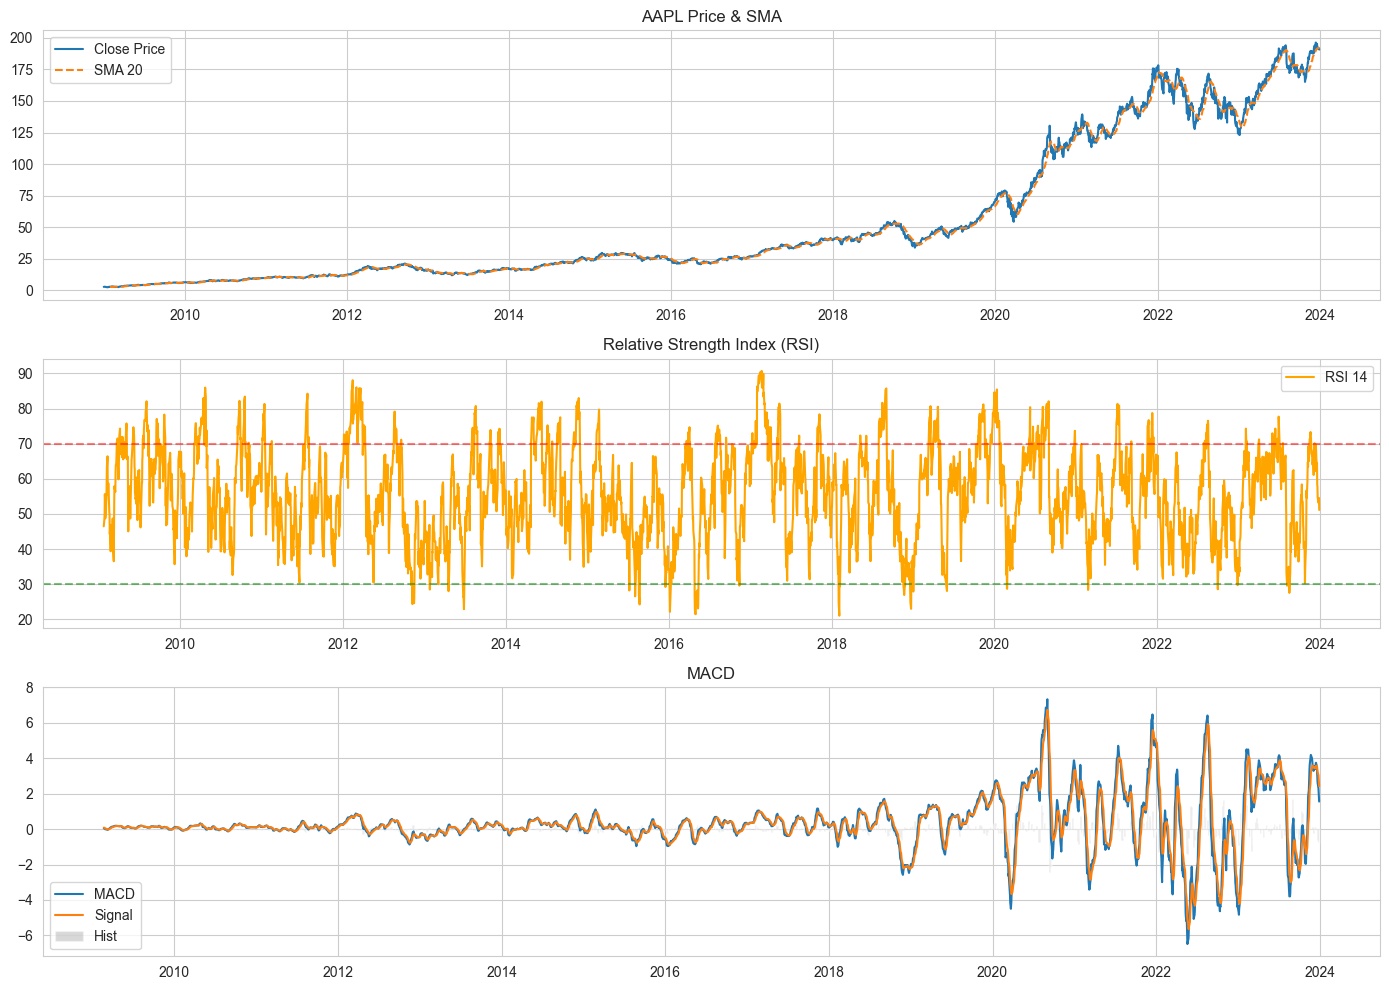

In [7]:
plt.figure(figsize=(14, 10))

# Price and SMA
plt.subplot(3, 1, 1)
plt.plot(df_ta.index, df_ta['Close'], label='Close Price')
plt.plot(df_ta.index, df_ta['SMA_20'], label='SMA 20', linestyle='--')
plt.title(f'{ticker} Price & SMA')
plt.legend()

# RSI
plt.subplot(3, 1, 2)
plt.plot(df_ta.index, df_ta['RSI_14'], color='orange', label='RSI 14')
plt.axhline(70, linestyle='--', color='red', alpha=0.5)
plt.axhline(30, linestyle='--', color='green', alpha=0.5)
plt.title('Relative Strength Index (RSI)')
plt.legend()

# MACD
plt.subplot(3, 1, 3)
plt.plot(df_ta.index, df_ta['MACD'], label='MACD')
plt.plot(df_ta.index, df_ta['MACD_signal'], label='Signal')
plt.bar(df_ta.index, df_ta['MACD_hist'], label='Hist', alpha=0.3, color='gray')
plt.title('MACD')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Financial Metrics (PyNance / Pandas)

In [8]:
# Calculate metrics for all loaded stocks
results = []

for t, data in stock_data.items():
    # Apply indicators first (needed for some metrics if they rely on them, though our current metrics function uses Close)
    data_ta = apply_technical_indicators(data)
    
    metrics = calculate_financial_metrics(data_ta)
    metrics['Ticker'] = t
    results.append(metrics)

metrics_df = pd.DataFrame(results)
# Reorder columns to put Ticker first
cols = ['Ticker'] + [c for c in metrics_df.columns if c != 'Ticker']
metrics_df = metrics_df[cols]

print('Financial Metrics Summary:')
display(metrics_df)

Financial Metrics Summary:


,Ticker,volatility,cumulative_return,max_drawdown
0,AAPL,0.285902,69.077426,-0.437971
1,AMZN,0.346528,54.901400,-0.561453
2,GOOG,0.275161,16.609641,-0.446019
3,META,0.401306,8.258698,-0.767361
4,MSFT,0.268038,23.958636,-0.371485
5,NVDA,0.459048,246.917539,-0.663351
